In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import cariaco_npzd_setups as cns          # NPZD model (replaces cariaco_baseline_setups)
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cns, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cns.phyto_esd, cns.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')
print(f'spec: K_sZ={cns.K_SZ}  σ={cns.SIGMA}  GGE={cns.GGE_VAL}  '
      f'm_Z={cns.M_Z}  m_Zlin={cns.M_ZLIN}  θ_opt={cns.THETA_OPT}  '
      f'fish_rate(default)={cns.FISH_RATE}')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)
spec: K_sZ=0.23  σ=0.15  GGE=0.25  m_Z=0.1  m_Zlin=0.05  θ_opt=10.0  fish_rate(default)=0.0


In [3]:
# ---- Cell 1 — imports + single full-output reference run -----------------------
# Pull phiPZ, KsZ, Imax from one full-output run so the kernel comes straight from
# the model's own output Dataset (single source of truth).
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import importlib

import cariaco_npzd_setups as ns
import cariaco_obs as co
import parscan_utils as pu

importlib.reload(ns); importlib.reload(co); importlib.reload(pu)

# Upwelling regime forcing (used to drive both the kernel-reference run and the scan)
*_, mdf, forcing = co.load_cariaco_targets('upwelling', months='hplc',
                                           agg='median', include_temperature=True)
T_box = float(forcing['Temperature__value'])
print(f"Forcing: F_N={forcing['Inflow__FN']:.3f}, d_e={forcing['Inflow__de']:.2f}, T={T_box:.2f} °C")

# Single full-output baseline run at the upwelling forcing.
# Use the FULL setup (model_setup_npzd_tani) so phiPZ, KsZ, Imax and the grazing
# matrix are all on the output Dataset.
out_ref = pu.run_single_point(
    model=ns.model_npzd,
    model_setup=ns.model_setup_npzd_tani,
    scan_params={},
    fixed_overrides={**forcing,
                     'PhytoMortality__rate': np.full(ns.N_CLASSES, 0.02)},
)

# Single source of truth — read kernel + parameters off the model's output:
phiPZ = out_ref['Grazing__phiPZ'].values                # (n_P+n_Z, n_Z)
KsZ   = float(out_ref['Grazing__KsZ'].values[0])       # uniform; per-zoo array
Imax  = out_ref['Grazing__Imax'].values                # (n_Z,)
Q10_GRAZE, T_REF = 2.48, 20.0
f_T = Q10_GRAZE ** ((T_box - T_REF) / 10.0)
n_P = ns.phyto_esd.size; n_Z = ns.zoo_esd.size
print(f"phiPZ shape={phiPZ.shape}, KsZ={KsZ}, f_T={f_T:.3f}")

Forcing: F_N=2.579, d_e=42.79, T=23.00 °C
phiPZ shape=(80, 40), KsZ=0.23, f_T=1.313


In [5]:
# ---- Cell 3 — slim F_N parscan (corrected: single Dataset return + avg_tail) --
from xso.parscans import run_xso_parscan

FN_VALUES = np.linspace(0.5, 12.0, 30)
fixed_for_scan = {k: v for k, v in forcing.items() if k != 'Inflow__FN'}
fixed_for_scan['PhytoMortality__rate'] = np.full(ns.N_CLASSES, 0.02)

scan = run_xso_parscan(
    model_file_name='cariaco_npzd_setups',
    model_name='model_npzd',
    model_setup_name='model_setup_npzd_tani_scan',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=fixed_for_scan,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
print(f"scan dims: {dict(scan.dims)}")
print(f"first 6 vars: {list(scan.data_vars)[:6]}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 41.21133 seconds.
scan dims: {'Inflow__FN': 30, 'time': 1, 'phyto': 40, 'zoo': 40, 'full': 80}
first 6 vars: ['Detritus__value', 'Nutrient__value', 'Phytoplankton__biomass', 'Time__time_input', 'Zooplankton__biomass', 'Core__solver_kwargs']


In [6]:
# ---- Cell 4 — compute S_j, f_sat,j, mcs(F_N) from the assembled scan ----------
# scan is one Dataset; dims include 'Inflow__FN' and a length-1 'time'.
P_scan = scan['Phytoplankton__biomass'].squeeze('time').values       # (n_FN, n_P)
Z_scan = scan['Zooplankton__biomass'].squeeze('time').values         # (n_FN, n_Z)

# If parscan returns FN as a non-monotone axis, sort everything by FN ascending
FN_axis = scan['Inflow__FN'].values
order   = np.argsort(FN_axis)
FN_VALUES = FN_axis[order]
P_scan, Z_scan = P_scan[order], Z_scan[order]

B_scan = np.concatenate([P_scan, Z_scan], axis=1)                    # (n_FN, n_full)
S_scan = np.einsum('kj,fk->fj', phiPZ, B_scan)                       # (n_FN, n_Z)
f_sat  = S_scan**2 / (S_scan**2 + KsZ**2)                            # (n_FN, n_Z)

log_esd = np.log10(ns.phyto_esd)
mcs = (P_scan * log_esd[None, :]).sum(axis=1) / P_scan.sum(axis=1)
mcs_peak_idx = int(np.argmax(mcs))
mcs_peak_FN  = FN_VALUES[mcs_peak_idx]
print(f"mcs peak at F_N ≈ {mcs_peak_FN:.2f}  (log10 ESD = {mcs[mcs_peak_idx]:.3f})")

mcs peak at F_N ≈ 4.86  (log10 ESD = 0.855)


In [7]:
# ---- Cell 8 — isolation setup + helper ----------------------------------------
# Pull everything from the setups module (single source of truth at setup level).
# Call DistributedGrazing_TypeIII_T.fluxes.grazing directly with prescribed
# biomass — no ODE integration, no model run.
from cariaco_npzd_comps import DistributedGrazing_TypeIII_T as DGT

phiPZ_iso = ns.phiPZ_omni                     # (n_full, n_Z)
KsZ_iso   = ns.KsZ_arr                        # (n_Z,) — uniform K_SZ
Imax_iso  = ns.Imax_arr                       # (n_Z,)
KsZ_scalar = float(ns.K_SZ)
n_P, n_Z = ns.phyto_esd.size, ns.zoo_esd.size

# Baseline biomass = realised SS at the mcs peak (from the F_N scan above)
P_base = P_scan[mcs_peak_idx].copy()
Z_base = Z_scan[mcs_peak_idx].copy()
T_iso  = T_box                                # upwelling-regime temperature

def graze_response(P, Z, T=T_iso, ksz=KsZ_scalar):
    """Compute S_j, f_sat_j, and the model G_kj matrix for prescribed biomass.
    G comes from the comp's own flux method — same code path as the model uses."""
    B = np.concatenate([P, Z])
    S = (phiPZ_iso * B[:, None]).sum(axis=0)                                   # (n_Z,)
    f_sat = S**2 / (S**2 + ksz**2)
    G = DGT.fluxes.grazing(resource=P, consumer=Z, temperature=T,
                           phiPZ=phiPZ_iso, Imax=Imax_iso, KsZ=KsZ_iso,
                           q10=2.48, t_ref=20.0)                              # (n_full, n_Z)
    return S, f_sat, G

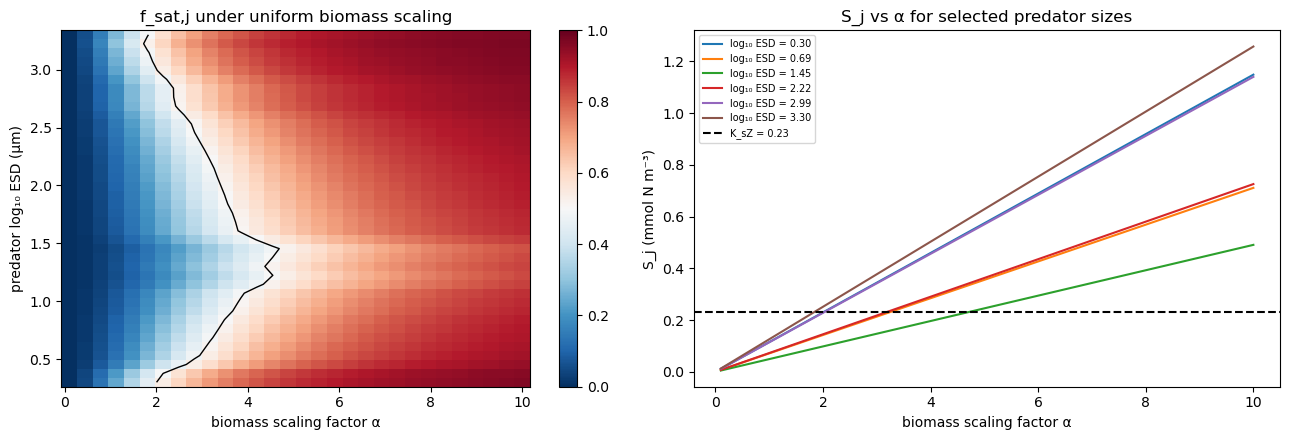

In [8]:
# ---- Cell 9 — Test 1: uniform biomass scaling ---------------------------------
# Scale realised-SS biomass by α; ask whether anything crosses K_sZ even at α=10.
alphas = np.linspace(0.1, 10.0, 30)
f_sat_alpha = np.zeros((alphas.size, n_Z))
S_alpha     = np.zeros((alphas.size, n_Z))
for i, a in enumerate(alphas):
    S, fs, _ = graze_response(a * P_base, a * Z_base)
    S_alpha[i] = S; f_sat_alpha[i] = fs

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im = axes[0].pcolormesh(alphas, np.log10(ns.zoo_esd), f_sat_alpha.T,
                        vmin=0, vmax=1, cmap='RdBu_r', shading='nearest')
axes[0].contour(alphas, np.log10(ns.zoo_esd), f_sat_alpha.T,
                levels=[0.5], colors='k', linewidths=1.0)
axes[0].set_xlabel('biomass scaling factor α'); axes[0].set_ylabel('predator log₁₀ ESD (µm)')
axes[0].set_title('f_sat,j under uniform biomass scaling')
fig.colorbar(im, ax=axes[0])

# Per-predator S_j vs α with K_sZ reference line
for j in [0, 5, 15, 25, 35, n_Z-1]:
    axes[1].plot(alphas, S_alpha[:, j], label=f'log₁₀ ESD = {np.log10(ns.zoo_esd[j]):.2f}')
axes[1].axhline(KsZ_scalar, color='k', ls='--', label=f'K_sZ = {KsZ_scalar}')
axes[1].set_xlabel('biomass scaling factor α'); axes[1].set_ylabel('S_j (mmol N m⁻³)')
axes[1].set_title('S_j vs α for selected predator sizes'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

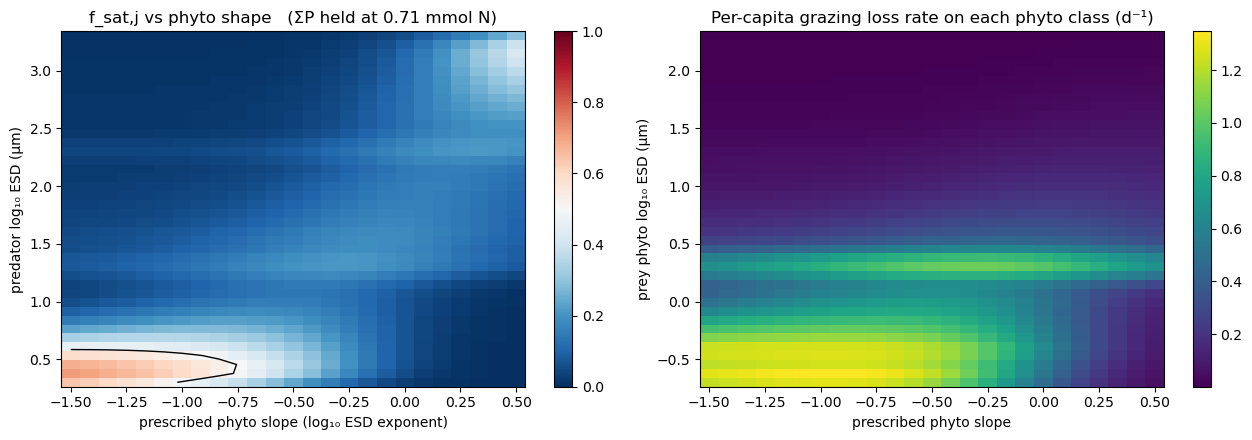

In [9]:
# ---- Cell 10 — Test 2: shape variation at fixed total phyto biomass -----------
# Hold ΣP = ΣP_ref; vary phyto distribution slope from Pico-heavy to Micro-heavy.
# Zoo biomass held at realised SS.
P_total = P_base.sum()
slopes  = np.linspace(-1.5, 0.5, 25)                                # log10 ESD slope
log_esd_p = np.log10(ns.phyto_esd)

f_sat_slope  = np.zeros((slopes.size, n_Z))
loss_per_prey = np.zeros((slopes.size, n_P))                        # per-cap loss rate on phyto k
for i, s in enumerate(slopes):
    shape  = ns.phyto_esd ** s
    P_s    = P_total * shape / shape.sum()
    S, fs, G = graze_response(P_s, Z_base)
    f_sat_slope[i]   = fs
    loss_per_prey[i] = G[:n_P, :].sum(axis=1) / np.maximum(P_s, 1e-30)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im0 = axes[0].pcolormesh(slopes, np.log10(ns.zoo_esd), f_sat_slope.T,
                         vmin=0, vmax=1, cmap='RdBu_r', shading='nearest')
axes[0].contour(slopes, np.log10(ns.zoo_esd), f_sat_slope.T,
                levels=[0.5], colors='k', linewidths=1.0)
axes[0].set_xlabel('prescribed phyto slope (log₁₀ ESD exponent)')
axes[0].set_ylabel('predator log₁₀ ESD (µm)')
axes[0].set_title(f'f_sat,j vs phyto shape   (ΣP held at {P_total:.2f} mmol N)')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(slopes, np.log10(ns.phyto_esd), loss_per_prey.T,
                         cmap='viridis', shading='nearest')
axes[1].set_xlabel('prescribed phyto slope')
axes[1].set_ylabel('prey phyto log₁₀ ESD (µm)')
axes[1].set_title('Per-capita grazing loss rate on each phyto class (d⁻¹)')
fig.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()

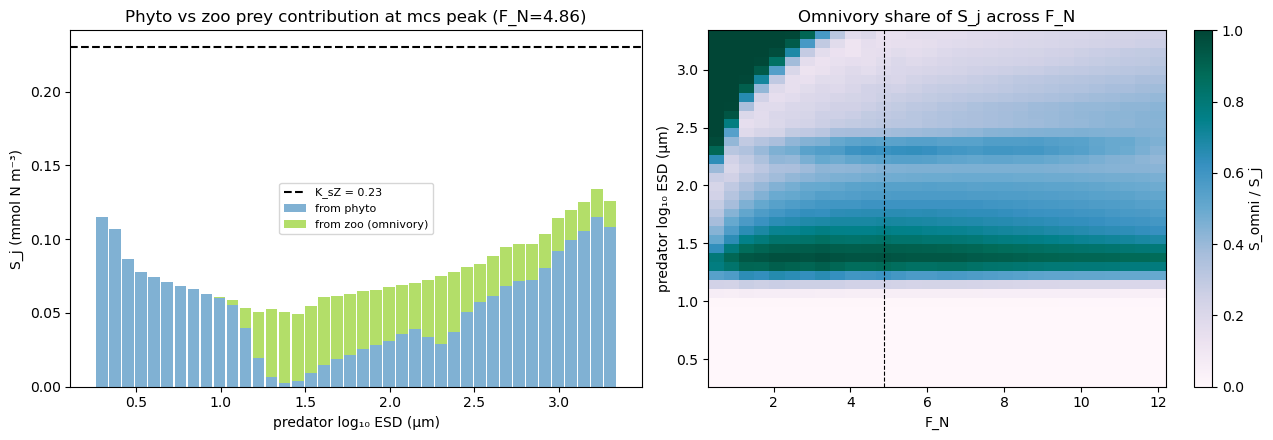

In [10]:
# ---- Cell 11 — Test 3: herbivory vs omnivory channel decomposition ------------
# At each realised-SS F_N, split S_j into the contribution from phyto-prey vs
# zoo-prey. Diagnoses how much of the U-shape comes from omnivory.
S_herb = np.einsum('kj,fk->fj', phiPZ_iso[:n_P, :],   P_scan)        # (n_FN, n_Z)
S_omni = np.einsum('kj,fk->fj', phiPZ_iso[n_P:, :],   Z_scan)        # (n_FN, n_Z)
share_omni = S_omni / np.maximum(S_herb + S_omni, 1e-30)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Stacked at the mcs peak F_N
xj = np.log10(ns.zoo_esd)
axes[0].bar(xj, S_herb[mcs_peak_idx], width=0.07, label='from phyto', color='#80b1d3')
axes[0].bar(xj, S_omni[mcs_peak_idx], width=0.07, bottom=S_herb[mcs_peak_idx],
            label='from zoo (omnivory)', color='#b3de69')
axes[0].axhline(KsZ_scalar, color='k', ls='--', label=f'K_sZ = {KsZ_scalar}')
axes[0].set_xlabel('predator log₁₀ ESD (µm)'); axes[0].set_ylabel('S_j (mmol N m⁻³)')
axes[0].set_title(f'Phyto vs zoo prey contribution at mcs peak (F_N={mcs_peak_FN:.2f})')
axes[0].legend(fontsize=8)

im = axes[1].pcolormesh(FN_VALUES, np.log10(ns.zoo_esd), share_omni.T,
                        vmin=0, vmax=1, cmap='PuBuGn', shading='nearest')
axes[1].axvline(mcs_peak_FN, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('predator log₁₀ ESD (µm)')
axes[1].set_title('Omnivory share of S_j across F_N')
fig.colorbar(im, ax=axes[1], label='S_omni / S_j')
plt.tight_layout(); plt.show()

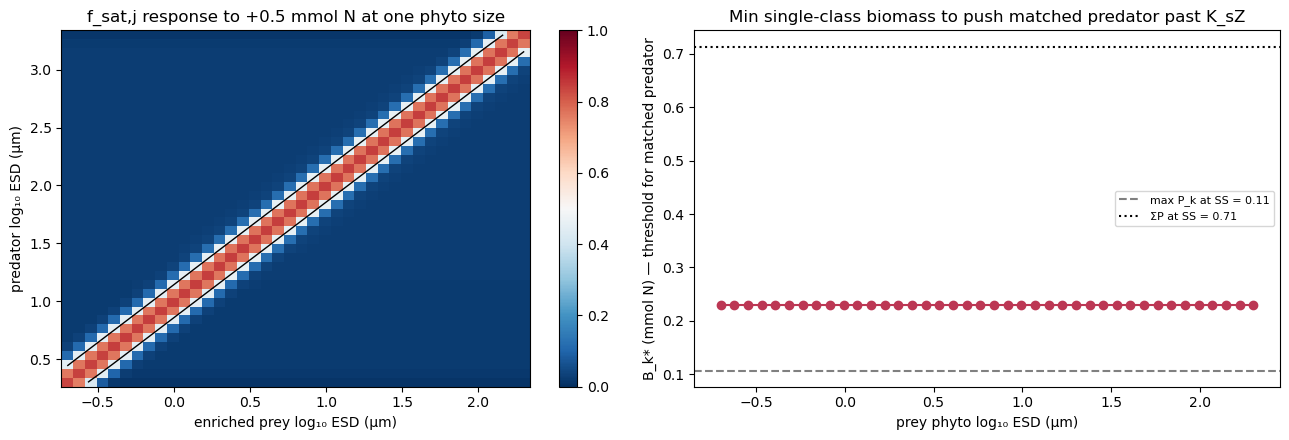

In [11]:
# ---- Cell 12 — Test 4: single-size delta enrichment + analytical threshold ----
# Baseline = flat low biomass everywhere; enrich one phyto class at a time and
# measure the matched predator's response.
P_flat = np.full(n_P, 0.01)
Z_flat = np.full(n_Z, 0.001)
delta  = 0.5                                                     # mmol N added

# (A) Enrichment heatmap: f_sat,j response when prey class k is enriched.
f_sat_enrich = np.zeros((n_P, n_Z))
for k in range(n_P):
    P_k = P_flat.copy(); P_k[k] += delta
    _, fs, _ = graze_response(P_k, Z_flat)
    f_sat_enrich[k] = fs

# (B) Analytical threshold: minimum B_k needed to push the kernel-matched
#     predator past K_sZ via that prey class alone (ignoring other contributions).
j_match    = np.argmax(phiPZ_iso[:n_P, :], axis=1)                # matched predator per phyto k
phi_match  = phiPZ_iso[np.arange(n_P), j_match]
B_k_thresh = KsZ_scalar / phi_match                              # mmol N — analytical

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im = axes[0].pcolormesh(np.log10(ns.phyto_esd), np.log10(ns.zoo_esd),
                        f_sat_enrich.T, vmin=0, vmax=1, cmap='RdBu_r',
                        shading='nearest')
axes[0].contour(np.log10(ns.phyto_esd), np.log10(ns.zoo_esd), f_sat_enrich.T,
                levels=[0.5], colors='k', linewidths=1.0)
axes[0].set_xlabel('enriched prey log₁₀ ESD (µm)')
axes[0].set_ylabel('predator log₁₀ ESD (µm)')
axes[0].set_title(f'f_sat,j response to +{delta} mmol N at one phyto size')
fig.colorbar(im, ax=axes[0])

axes[1].plot(np.log10(ns.phyto_esd), B_k_thresh, 'o-', color='#bc3754')
axes[1].axhline(P_base.max(),  color='gray', ls='--', label=f'max P_k at SS = {P_base.max():.2f}')
axes[1].axhline(P_base.sum(),  color='k',    ls=':',  label=f'ΣP at SS = {P_base.sum():.2f}')
axes[1].set_xlabel('prey phyto log₁₀ ESD (µm)')
axes[1].set_ylabel('B_k* (mmol N) — threshold for matched predator')
axes[1].set_title('Min single-class biomass to push matched predator past K_sZ')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

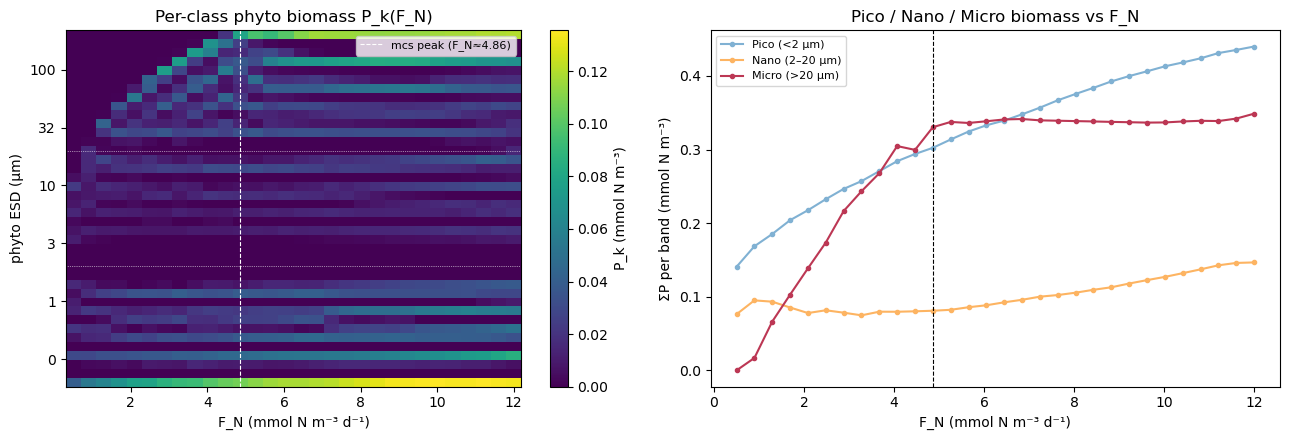

   F_N     Pico     Nano    Micro  (mmol N m⁻³)
  4.47    0.294    0.080    0.300
  4.86    0.302    0.081    0.330
  5.26    0.314    0.082    0.337
  5.66    0.324    0.086    0.336
  6.05    0.333    0.088    0.338
  6.45    0.339    0.092    0.341
  6.84    0.348    0.096    0.341
  7.24    0.357    0.100    0.340
  7.64    0.367    0.102    0.339
  8.03    0.376    0.106    0.339
  8.43    0.384    0.110    0.338
  8.83    0.393    0.113    0.338
  9.22    0.400    0.118    0.337
  9.62    0.406    0.123    0.337
 10.02    0.413    0.127    0.337
 10.41    0.418    0.132    0.338
 10.81    0.424    0.137    0.339
 11.21    0.431    0.143    0.339
 11.60    0.435    0.146    0.342
 12.00    0.440    0.147    0.349


In [13]:
n_FN = len(FN_VALUES)
from matplotlib.ticker import FuncFormatter
fmt = FuncFormatter(lambda x, _: f'{10**x:.0f}')

# ---- Cell 13 — per-class phyto biomass across F_N (descending-limb check) ----
# Heatmap of P_k(F_N) plus per-band totals (Pico/Nano/Micro) on the same F_N axis.
phyto_log_esd = np.log10(ns.phyto_esd)

# Band masks (Sieburth convention)
m_pico  = ns.phyto_esd < 2.0
m_nano  = (ns.phyto_esd >= 2.0) & (ns.phyto_esd < 20.0)
m_micro = ns.phyto_esd >= 20.0

P_pico  = P_scan[:, m_pico].sum(axis=1)
P_nano  = P_scan[:, m_nano].sum(axis=1)
P_micro = P_scan[:, m_micro].sum(axis=1)

fmt = FuncFormatter(lambda x, _: f'{10**x:.0f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1 — per-class biomass heatmap (linear colour to see plateaus directly)
im = axes[0].pcolormesh(FN_VALUES, phyto_log_esd, P_scan.T,
                        cmap='viridis', shading='nearest')
axes[0].axvline(mcs_peak_FN, color='w', lw=0.8, ls='--', label=f'mcs peak (F_N≈{mcs_peak_FN:.2f})')
# Sieburth band boundaries (2 µm and 20 µm)
for esd_b in (2.0, 20.0):
    axes[0].axhline(np.log10(esd_b), color='w', lw=0.5, ls=':')
axes[0].yaxis.set_major_formatter(fmt)
axes[0].set_xlabel('F_N (mmol N m⁻³ d⁻¹)')
axes[0].set_ylabel('phyto ESD (µm)')
axes[0].set_title('Per-class phyto biomass P_k(F_N)')
axes[0].legend(loc='upper right', fontsize=8)
fig.colorbar(im, ax=axes[0], label='P_k (mmol N m⁻³)')

# Panel 2 — per-band totals on linear axes
axes[1].plot(FN_VALUES, P_pico,  '-o', color='#80b1d3', label='Pico (<2 µm)',     ms=3)
axes[1].plot(FN_VALUES, P_nano,  '-o', color='#fdb462', label='Nano (2–20 µm)',   ms=3)
axes[1].plot(FN_VALUES, P_micro, '-o', color='#bc3754', label='Micro (>20 µm)',   ms=3)
axes[1].axvline(mcs_peak_FN, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('F_N (mmol N m⁻³ d⁻¹)')
axes[1].set_ylabel('ΣP per band (mmol N m⁻³)')
axes[1].set_title('Pico / Nano / Micro biomass vs F_N')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Concrete numbers across the descending limb
print(f"{'F_N':>6} {'Pico':>8} {'Nano':>8} {'Micro':>8}  (mmol N m⁻³)")
for i, fn in enumerate(FN_VALUES):
    if fn >= mcs_peak_FN - 0.5:
        print(f"{fn:6.2f} {P_pico[i]:8.3f} {P_nano[i]:8.3f} {P_micro[i]:8.3f}")

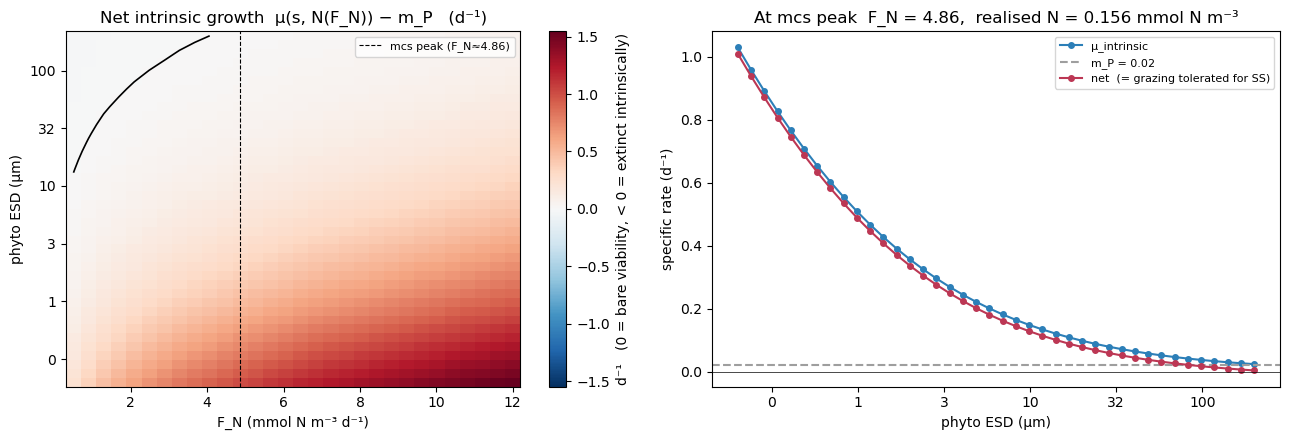


Descending-limb endpoint  F_N = 12.00, realised N = 0.5098 mmol N m⁻³:
   Pico  (n=13): μ_intrinsic mean = 1.158 d⁻¹, net mean = 1.138 d⁻¹
   Nano  (n=13): μ_intrinsic mean = 0.489 d⁻¹, net mean = 0.469 d⁻¹
   Micro (n=13): μ_intrinsic mean = 0.157 d⁻¹, net mean = 0.137 d⁻¹


In [15]:
# ---- Cell 14 — Angle A: per-class intrinsic growth ceiling vs F_N -------------
# At each F_N pull the realised SS nutrient N(F_N), then compute the per-class
# intrinsic specific growth μ(s, N(F_N)) by calling the growth comp directly.
from cariaco_npzd_comps import MonodGrowth_T

Q10_GROW    = 1.62                                           # Cloern (growth)
m_P_uniform = 0.02                                           # uniform baseline

# Realised SS nutrient at each F_N (from the slim scan)
N_scan = scan['Nutrient__value'].squeeze('time').values[order]    # (n_FN,)

# Per-class intrinsic specific growth via the comp's own flux method
# (consumer=1 → return is the specific rate, not the absolute uptake flux).
mu_intrinsic = np.zeros((n_FN, n_P))
for i, N_i in enumerate(N_scan):
    mu_intrinsic[i] = MonodGrowth_T.fluxes.uptake(
        resource=N_i, consumer=np.ones(n_P), temperature=T_box,
        mu_max=ns.mu_max_tani, halfsat=ns.ks_tani,
        q10=Q10_GROW, t_ref=T_REF,
    )
net = mu_intrinsic - m_P_uniform                                  # (n_FN, n_P)

fmt = FuncFormatter(lambda x, _: f'{10**x:.0f}')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1 — net intrinsic growth heatmap with 0-contour (viability boundary)
vmax = np.max(np.abs(net))
im = axes[0].pcolormesh(FN_VALUES, np.log10(ns.phyto_esd), net.T,
                        cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='nearest')
axes[0].contour(FN_VALUES, np.log10(ns.phyto_esd), net.T,
                levels=[0], colors='k', linewidths=1.2)
axes[0].axvline(mcs_peak_FN, color='k', lw=0.8, ls='--', label=f'mcs peak (F_N≈{mcs_peak_FN:.2f})')
axes[0].yaxis.set_major_formatter(fmt)
axes[0].set_xlabel('F_N (mmol N m⁻³ d⁻¹)')
axes[0].set_ylabel('phyto ESD (µm)')
axes[0].set_title('Net intrinsic growth  μ(s, N(F_N)) − m_P   (d⁻¹)')
axes[0].legend(loc='upper right', fontsize=8)
fig.colorbar(im, ax=axes[0], label='d⁻¹   (0 = bare viability, < 0 = extinct intrinsically)')

# Panel 2 — at the mcs peak: intrinsic μ, mortality line, and net (= grazing tolerated)
ip = mcs_peak_idx
axes[1].plot(np.log10(ns.phyto_esd), mu_intrinsic[ip], '-o', color='#2c7fb8',
             label='μ_intrinsic', ms=4)
axes[1].axhline(m_P_uniform, color='#9e9e9e', ls='--', label=f'm_P = {m_P_uniform}')
axes[1].plot(np.log10(ns.phyto_esd), net[ip], '-o', color='#bc3754',
             label='net  (= grazing tolerated for SS)', ms=4)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].xaxis.set_major_formatter(fmt)
axes[1].set_xlabel('phyto ESD (µm)')
axes[1].set_ylabel('specific rate (d⁻¹)')
axes[1].set_title(f'At mcs peak  F_N = {mcs_peak_FN:.2f},  realised N = {N_scan[ip]:.3f} mmol N m⁻³')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# How much grazing can each band absorb at the descending-limb endpoint?
print(f"\nDescending-limb endpoint  F_N = {FN_VALUES[-1]:.2f}, "
      f"realised N = {N_scan[-1]:.4f} mmol N m⁻³:")
for esd_lo, esd_hi, lbl in [(0, 2, 'Pico'), (2, 20, 'Nano'), (20, 200, 'Micro')]:
    band = (ns.phyto_esd >= esd_lo) & (ns.phyto_esd < esd_hi)
    print(f"   {lbl:<5} (n={band.sum()}): "
          f"μ_intrinsic mean = {mu_intrinsic[-1][band].mean():.3f} d⁻¹, "
          f"net mean = {net[-1][band].mean():.3f} d⁻¹")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 43.41669 seconds.


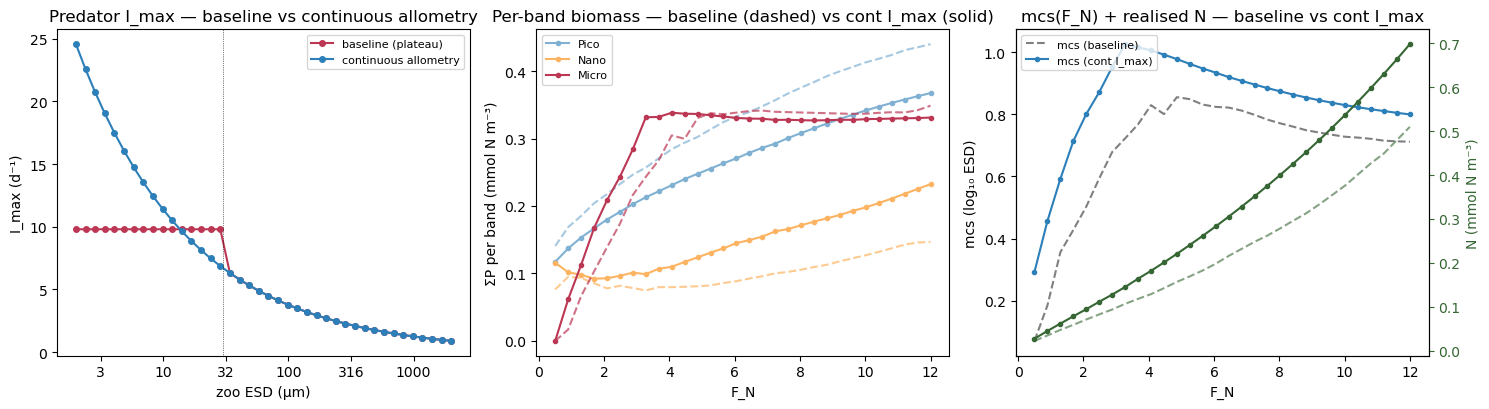

In [16]:
# ---- Cell 15 — continuous-allometry I_max check (Dutkiewicz plateau off) -----
# Override Grazing__Imax with a continuous Hansen-Imax allometry across all zoo.
zoo_vol = (np.pi / 6.0) * ns.zoo_esd ** 3
Imax_cont = 30.9 * zoo_vol ** (-0.16)                              # continuous

fixed_cont = dict(fixed_for_scan)
fixed_cont['Grazing__Imax'] = Imax_cont                            # array override

scan_cont = run_xso_parscan(
    model_file_name='cariaco_npzd_setups',
    model_name='model_npzd',
    model_setup_name='model_setup_npzd_tani_scan',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=fixed_cont,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)

# Extract + sort
FN_c    = scan_cont['Inflow__FN'].values
ord_c   = np.argsort(FN_c)
FN_c    = FN_c[ord_c]
P_cont  = scan_cont['Phytoplankton__biomass'].squeeze('time').values[ord_c]
N_cont  = scan_cont['Nutrient__value'].squeeze('time').values[ord_c]

P_pico_c  = P_cont[:, m_pico ].sum(axis=1)
P_nano_c  = P_cont[:, m_nano ].sum(axis=1)
P_micro_c = P_cont[:, m_micro].sum(axis=1)
mcs_c     = (P_cont * np.log10(ns.phyto_esd)[None, :]).sum(axis=1) / P_cont.sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (1) I_max baseline vs continuous
axes[0].plot(np.log10(ns.zoo_esd), ns.Imax_arr, '-o', color='#bc3754',
             label='baseline (plateau)', ms=4)
axes[0].plot(np.log10(ns.zoo_esd), Imax_cont,  '-o', color='#2c7fb8',
             label='continuous allometry', ms=4)
axes[0].axvline(np.log10(30.0), color='k', lw=0.5, ls=':')
axes[0].xaxis.set_major_formatter(fmt)
axes[0].set_xlabel('zoo ESD (µm)'); axes[0].set_ylabel('I_max (d⁻¹)')
axes[0].set_title('Predator I_max — baseline vs continuous allometry')
axes[0].legend(fontsize=8)

# (2) Per-band biomass overlay (dashed = baseline, solid = cont)
for arr, arr_c, col, lbl in [
    (P_pico,  P_pico_c,  '#80b1d3', 'Pico'),
    (P_nano,  P_nano_c,  '#fdb462', 'Nano'),
    (P_micro, P_micro_c, '#bc3754', 'Micro'),
]:
    axes[1].plot(FN_VALUES, arr,    '--', color=col, alpha=0.7)
    axes[1].plot(FN_c,      arr_c,  '-o', color=col, label=lbl, ms=3)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP per band (mmol N m⁻³)')
axes[1].set_title('Per-band biomass — baseline (dashed) vs cont I_max (solid)')
axes[1].legend(fontsize=8)

# (3) mcs(F_N) and realised N comparison
axes[2].plot(FN_VALUES, mcs,   '--', color='gray',    label='mcs (baseline)')
axes[2].plot(FN_c,      mcs_c, '-o', color='#2c7fb8', label='mcs (cont I_max)', ms=3)
ax2 = axes[2].twinx()
ax2.plot(FN_VALUES, N_scan, '--', color='#356633', alpha=0.6)
ax2.plot(FN_c,      N_cont, '-o', color='#356633', ms=3, label='N (cont)')
ax2.set_ylabel('N (mmol N m⁻³)', color='#356633'); ax2.tick_params(colors='#356633')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('mcs (log₁₀ ESD)')
axes[2].set_title('mcs(F_N) + realised N — baseline vs cont I_max')
axes[2].legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

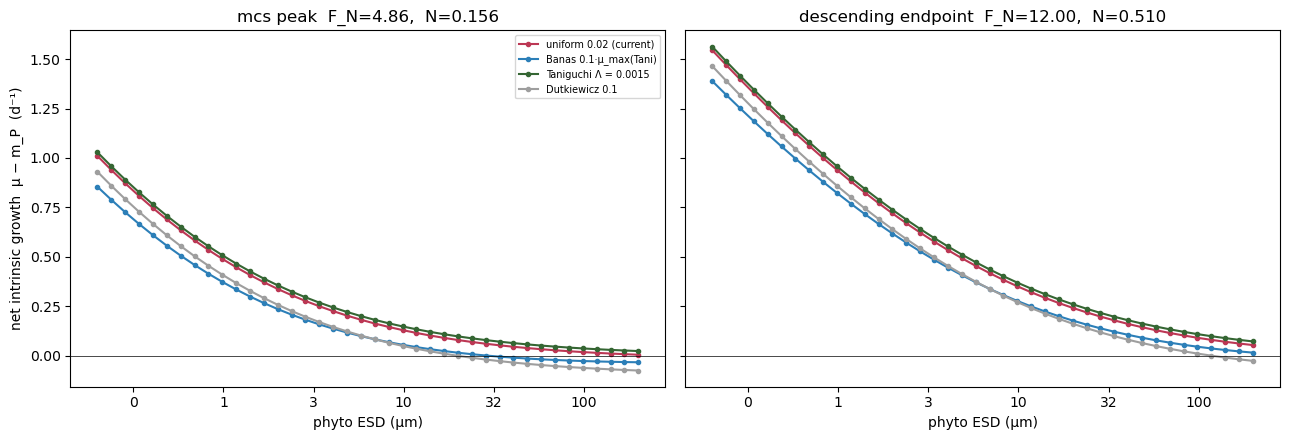


Descending endpoint F_N = 12.00, N = 0.510:
mortality form                   Pico     Nano    Micro   Pico/Micro
uniform 0.02 (current)          1.138    0.469    0.131          8.7×
Banas 0.1·μ_max(Tani)           1.009    0.386    0.081         12.5×
Taniguchi Λ = 0.0015            1.156    0.487    0.150          7.7×
Dutkiewicz 0.1                  1.058    0.389    0.051         20.7×


In [17]:
# ---- Cell 16 — Angle B: mortality form sensitivity (pure arithmetic) ---------
# Use μ_intrinsic from Cell 14 (Taniguchi growth × realised baseline N(F_N)).
m_P_forms = {
    'uniform 0.02 (current)':  np.full(n_P, 0.02),
    'Banas 0.1·μ_max(Tani)':   0.10 * ns.mu_max_tani,
    'Taniguchi Λ = 0.0015':     np.full(n_P, 0.0015),
    'Dutkiewicz 0.1':           np.full(n_P, 0.10),
}
colors_m = ['#bc3754', '#2c7fb8', '#356633', '#9e9e9e']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, idx, ttl in zip(
    axes, [mcs_peak_idx, n_FN - 1],
    [f'mcs peak  F_N={FN_VALUES[mcs_peak_idx]:.2f},  N={N_scan[mcs_peak_idx]:.3f}',
     f'descending endpoint  F_N={FN_VALUES[-1]:.2f},  N={N_scan[-1]:.3f}']):
    for (name, mp), col in zip(m_P_forms.items(), colors_m):
        ax.plot(np.log10(ns.phyto_esd), mu_intrinsic[idx] - mp, '-o',
                color=col, label=name, ms=3)
    ax.axhline(0, color='k', lw=0.5)
    ax.xaxis.set_major_formatter(fmt)
    ax.set_xlabel('phyto ESD (µm)')
    ax.set_title(ttl)
axes[0].set_ylabel('net intrinsic growth  μ − m_P  (d⁻¹)')
axes[0].legend(fontsize=7, loc='upper right')
plt.tight_layout(); plt.show()

# Band-mean net + Pico/Micro asymmetry ratio
print(f"\nDescending endpoint F_N = {FN_VALUES[-1]:.2f}, N = {N_scan[-1]:.3f}:")
print(f"{'mortality form':<28} {'Pico':>8} {'Nano':>8} {'Micro':>8}  {'Pico/Micro':>11}")
for name, mp in m_P_forms.items():
    n_end = mu_intrinsic[-1] - mp
    pico  = n_end[m_pico ].mean()
    nano  = n_end[m_nano ].mean()
    micro = n_end[m_micro].mean()
    ratio = pico / max(micro, 1e-6)
    print(f"{name:<28} {pico:8.3f} {nano:8.3f} {micro:8.3f}  {ratio:11.1f}×")